<a href="https://colab.research.google.com/github/angulorojasmariaclaudia-coder/TRABAJO-FINAL-AP-/blob/main/Trabajo_Final_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
Trabajo Final Aprendizaje Profundo
```

# **SEMI-SUPERVISED GENERATIVE ADVERSARIAL NETWORKS**

**Autoras:** Patricia Contreras - Maria Claudia Angulo

**Asignatura:** Aprendizaje Profundo — Máster en Ciencia de Datos  

**Tema:** Aprendizaje semi-supervisado en el contexto de las GANs  

**Material de referencia principal:** [Semi-Supervised Generative Adversarial Network — Machine Learning Mastery](https://machinelearningmastery.com/semi-supervised-generative-adversarial-network/)  

**Demo interactiva:**

[Hugging Face Spaces — colab-sgan-demo-versión-1](https://huggingface.co/spaces/Clau31/colab-sgan-demo)


[Hugging Face Spaces — colab-sgan-demo-versión-2](https://huggingface.co/spaces/Clau31/fashion-mnist-sgan-v2-demo)



***Resumen:***

*En este notebook vamos a ver cómo aplicar el aprendizaje semi-supervisado usando GANs. Concretamente, implementamos una **Semi-Supervised GAN (SGAN)** y la comparamos con una CNN supervisada convencional sobre el dataset **Fashion-MNIST**. Para poder ejecutarlo correctamente hay que activar la GPU.*


## **1. Introducción**

Uno de los problemas más habituales en aprendizaje automático es que etiquetar datos es caro y lento. A veces se necesitan expertos para etiquetar correctamente los datos, y eso hace que obtener conjuntos de entrenamiento grandes sea complicado.

El **aprendizaje semi-supervisado** intenta aprovechar tanto los pocos datos etiquetados que tenemos como grandes cantidades de datos sin etiqueta, que normalmente son mucho más fáciles de conseguir. La idea es que aunque los datos sin etiqueta no nos digan directamente qué clase tiene cada imagen, sí nos dan pistas sobre la estructura de los datos, lo que puede ayudar al clasificador.

Por otro lado, las **GANs (Redes Generativas Adversariales)** son modelos que aprenden a generar datos nuevos que parecen reales. Están formadas por dos redes: un generador que crea imágenes artificiales, y un discriminador que intenta distinguir si una imagen es real o generada.

En este trabajo combinamos ambas ideas: usamos una **Semi-Supervised GAN (SGAN)**, donde el discriminador de la GAN también aprende a **clasificar imágenes** en sus categorías, aprovechando a la vez los datos etiquetados, los no etiquetados y las imágenes que genera el generador.

Lo aplicamos al dataset **Fashion-MNIST**, con solo 10 imágenes etiquetadas por clase (100 en total), para ver si la SGAN mejora los resultados frente a una CNN entrenada únicamente con esas 100 imágenes.


## **2. Fundamentos Teóricos**

A continuación, se detallan los conceptos detras del SGAN.

### **2.1. ¿Qué es una GAN?**

Una **GAN** (Red Generativa Adversarial) está formada por dos redes que compiten entre sí:

- El **generador** recibe un vector de ruido aleatorio y lo transforma en una imagen artificial. Su objetivo es que las imágenes que genera parezcan lo más reales posible.
- El **discriminador** recibe imágenes —reales o generadas— y tiene que decidir si son reales o falsas.

Ambas redes se entrenan al mismo tiempo: el generador intenta engañar al discriminador, y el discriminador intenta no dejarse engañar. Con el tiempo, el generador aprende a producir imágenes cada vez más realistas.

### **2.2. ¿Qué es el aprendizaje semi-supervisado?**

El aprendizaje **semi-supervisado** usa una pequeña cantidad de datos etiquetados más una gran cantidad de datos sin etiquetar. La intuición es que los datos sin etiqueta, aunque no digan la clase concreta de cada imagen, sí aportan información sobre la estructura general de los datos, y eso puede mejorar la clasificación.

### **2.3. ¿Qué es una Semi-Supervised GAN?**

Una **SGAN** combina las dos ideas anteriores: adapta el discriminador de la GAN para que, además de distinguir imágenes reales de generadas, también **aprenda a clasificar imágenes** por categorías.

Durante el entrenamiento el discriminador ve tres tipos de imágenes:

| Tipo de imagen | Etiqueta | Qué aprende |
|---|---|---|
| Imágenes reales etiquetadas | Clase concreta (0–9) | A clasificar prendas |
| Imágenes reales sin etiqueta | "Real" | La estructura general de los datos |
| Imágenes generadas | "Falsa" | A detectar imágenes artificiales |

Al terminar el entrenamiento, la parte clasificadora del discriminador se usa como modelo final.

La función clave es `custom_activation`, que calcula la probabilidad de que una imagen sea "real" sumando las probabilidades de todas las clases reales y dividiéndola por esa suma más 1 (que representa la clase implícita "generada"):

```python
def custom_activation(x):
    ex = K.exp(x)
    sum_ex = K.sum(ex, axis=-1, keepdims=True)
    return sum_ex / (sum_ex + 1.0)
```

De esta forma, el mismo discriminador sirve tanto para clasificar prendas como para distinguir imágenes reales de generadas, compartiendo los mismos pesos internos.


## **3. Metodologia**

En esta sección describimos cómo hemos organizado el experimento: qué datos usamos, cómo preparamos el escenario semi-supervisado, qué modelos implementamos y cómo los evaluamos.

### **3.1. Dataset utilizado**

Usamos **Fashion-MNIST**, un conjunto de imágenes en escala de grises de 28 × 28 píxeles con 10 categorías de prendas y accesorios:

| Clase | Nombre |
|-------|--------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Elegimos Fashion-MNIST en lugar de MNIST porque las clases son más parecidas entre sí y resulta un problema más interesante y realista. Con MNIST los resultados serían demasiado fáciles de interpretar.

### **3.2. Preprocesamiento de los datos**

Las imágenes se normalizan al intervalo **[-1, 1]** con la fórmula $(x - 127.5) / 127.5$. Esto es necesario porque el generador usa `tanh` en su última capa, que produce salidas en ese mismo rango.

También se añade una dimensión de canal, pasando de 28 × 28 a 28 × 28 × 1, para que las capas convolucionales funcionen correctamente.

### **3.3. Creación del escenario semi-supervisado**

Aunque Fashion-MNIST tiene etiquetas para todas las imágenes, aquí solo usamos **10 etiquetas por clase** (100 en total), simulando un escenario donde los datos etiquetados son escasos. El resto de imágenes de entrenamiento se usan sin etiqueta para la parte adversarial.

| Conjunto | Contenido | Uso |
|---|---|---|
| `X_labeled` | 100 imágenes con etiqueta | Parte supervisada del discriminador |
| `y_labeled` | Etiquetas de esas 100 imágenes | Clase correcta |
| `X_train` | 60.000 imágenes sin etiqueta | Parte no supervisada del discriminador |
| Imágenes generadas | Creadas por el generador | Enseñar al discriminador a detectar imágenes falsas |
| `X_test`, `y_test` | 10.000 imágenes de test | Evaluación final |

### **3.4. Modelo baseline: CNN supervisada**

Antes de la SGAN, entrenamos una **CNN convencional** solo con las 100 imágenes etiquetadas, sin ningún componente generativo. Esto nos sirve de referencia para saber si la SGAN mejora o no los resultados.

### **3.5. Modelo principal: Semi-Supervised GAN**

La SGAN tiene:
- **Generador**: Transforma vectores de ruido de dimensión 100 en imágenes de 28 × 28 × 1.
- **Discriminador semi-supervisado**: Tiene una base convolucional compartida con dos salidas:
  - Salida **supervisada** (softmax de 10 clases) para clasificar prendas.
  - Salida **no supervisada** (`custom_activation`) para distinguir real/falso.

### **3.6. Entrenamiento de la SGAN**

En cada iteración del entrenamiento se hacen cuatro pasos:

1. Entrenar la parte supervisada del discriminador con imágenes etiquetadas.
2. Entrenar la parte no supervisada con imágenes reales (sin etiqueta).
3. Entrenar la parte no supervisada con imágenes generadas.
4. Entrenar el generador para que sus imágenes engañen al discriminador.

### **3.7. Funciones de pérdida**

- **Sparse Categorical Crossentropy**: para la clasificación en 10 clases.
- **Binary Crossentropy**: para la distinción real/fake.

### **3.8. Evaluación**

Evaluamos los modelos con accuracy global, informe de clasificación por clase, matriz de confusión, análisis visual de errores, curvas de entrenamiento e imágenes generadas.


## **4. Implementación**

En esta sección, se muestra el código completo del experimento. Seguimos el orden definido en la metodología, usando TensorFlow y Keras, e intentando que cada bloque de código esté bien explicado.

La implementación está basada en el enfoque del material de referencia del curso, adaptado a Fashion-MNIST.

### **4.1. Configuración inicial**

Primero importamos todas las librerías que necesitamos y fijamos una semilla aleatoria para que los resultados sean reproducibles.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, Conv2DTranspose, Flatten, Dropout,
    Reshape, LeakyReLU, BatchNormalization, MaxPooling2D, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### **4.2. Preparación de los datos**

#### **4.2.1. Carga del dataset**

Cargamos Fashion-MNIST directamente desde Keras. Separamos los datos en entrenamiento y test, y definimos los nombres de las 10 clases para usarlos en las visualizaciones.


In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


Visualizamos las primeras 10 imágenes del conjunto de entrenamiento para hacernos una idea de cómo es el dataset.

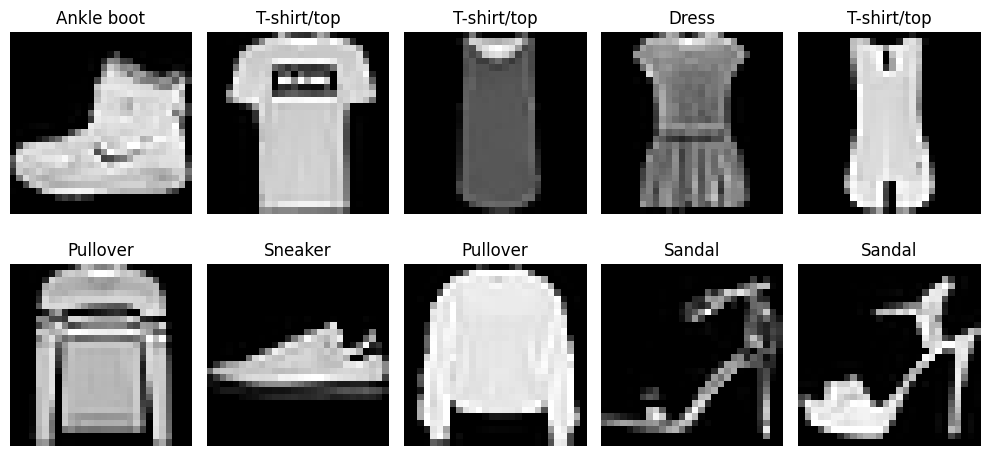

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### **4.2.2. Preprocesamiento de los datos**

Normalizamos las imágenes al rango [-1, 1] y añadimos la dimensión de canal. Ambos pasos son imprescindibles para que el generador y el discriminador funcionen correctamente.


In [ ]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train = (X_train - 127.5) / 127.5
X_test = (X_test - 127.5) / 127.5

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Rango X_train:", X_train.min(), X_train.max())

X_train: (60000, 28, 28, 1)
X_test: (10000, 28, 28, 1)
Rango X_train: -1.0 1.0


#### **4.2.3. Creación del subconjunto etiquetado**

Definimos una función que selecciona aleatoriamente un número fijo de imágenes por clase para crear el subconjunto etiquetado. El resultado es un conjunto equilibrado con el mismo número de ejemplos por categoría.


In [ ]:
def seleccionar_muestras_etiquetadas(X, y, n_por_clase=10):
    X_labeled = []
    y_labeled = []

    for clase in range(10):
        indices = np.where(y == clase)[0]
        seleccionados = np.random.choice(indices, n_por_clase, replace=False)

        X_labeled.append(X[seleccionados])
        y_labeled.append(y[seleccionados])

    X_labeled = np.vstack(X_labeled)
    y_labeled = np.hstack(y_labeled)

    return X_labeled, y_labeled

En el experimento usamos **10 imágenes por clase**, lo que da un total de **100 imágenes etiquetadas** de 60.000. Es una cantidad muy pequeña, lo que hace que el problema sea bastante difícil.

In [ ]:
N_POR_CLASE = 10

X_labeled, y_labeled = seleccionar_muestras_etiquetadas(
    X_train,
    y_train,
    n_por_clase=N_POR_CLASE
)

print("Imágenes etiquetadas:", X_labeled.shape)
print("Etiquetas:", y_labeled.shape)

Imágenes etiquetadas: (100, 28, 28, 1)
Etiquetas: (100,)


Comprobamos que la selección está equilibrada, es decir, que hay exactamente 10 imágenes etiquetadas de cada clase.

In [ ]:
unique, counts = np.unique(y_labeled, return_counts=True)

pd.DataFrame({
    "Clase": [class_names[i] for i in unique],
    "Número de imágenes etiquetadas": counts
})

,Clase,Número de imágenes etiquetadas
0,T-shirt/top,10
1,Trouser,10
2,Pullover,10
3,Dress,10
4,Coat,10
5,Sandal,10
6,Shirt,10
7,Sneaker,10
8,Bag,10
9,Ankle boot,10


### **4.3. Implementación del modelo baseline**

Antes de implementar la SGAN, entrenamos una **CNN convencional** solo con las 100 imágenes etiquetadas. Este modelo nos sirve de referencia para comparar después.

La arquitectura es sencilla: dos bloques convolucionales con max pooling y una capa densa final con softmax. No usa nada de datos no etiquetados ni ningún componente generativo.


In [ ]:
def crear_clasificador_baseline(input_shape=(28, 28, 1), n_classes=10):
    model = Sequential(name="baseline_cnn")

    model.add(Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation="relu"))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.4))
    model.add(Dense(n_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
baseline = crear_clasificador_baseline()
baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamos el baseline durante 40 épocas con las 100 imágenes etiquetadas y validamos sobre el test completo.

In [ ]:
history_baseline = baseline.fit(
    X_labeled,
    y_labeled,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.2100 - loss: 2.2556 - val_accuracy: 0.3893 - val_loss: 2.0961
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - accuracy: 0.4100 - loss: 1.9983 - val_accuracy: 0.5092 - val_loss: 1.8592
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.5100 - loss: 1.7518 - val_accuracy: 0.5668 - val_loss: 1.5751
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 0.5500 - loss: 1.5111 - val_accuracy: 0.6016 - val_loss: 1.3270
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.5600 - loss: 1.2283 - val_accuracy: 0.6362 - val_loss: 1.1461
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 892ms/step - accuracy: 0.6400 - loss: 1.1672 - val_accuracy: 0.6445 - val_loss: 1.0452
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 0.6900 - loss: 0.9433 - val_accuracy: 0.6516 - val_loss: 0.9564
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 442ms/step - accuracy: 0.6500 - loss: 0.9453 - val_accuracy: 0.6416 - val_loss: 0

In [ ]:
loss_baseline, acc_baseline = baseline.evaluate(X_test, y_test, verbose=0)

print("Accuracy baseline CNN:", acc_baseline)

Accuracy baseline CNN: 0.6776000261306763


### **4.4. Implementación de la SGAN**
A continuación, implementamos la parte principal del trabajo. Seguimos el enfoque del material de referencia, que se basa en **compartir los pesos** de la base convolucional entre el discriminador supervisado y el no supervisado.


#### **4.4.1. Discriminador semi-supervisado**

La clave del discriminador es que los dos modelos (supervisado y no supervisado) comparten exactamente la misma base convolucional y los mismos logits de salida. Solo difieren en la función de activación final.

La función `custom_activation` convierte los logits de clasificación en la probabilidad de que la imagen sea "real":

$$p(\text{real} \mid x) = \frac{\sum_{k=1}^{K} e^{l_k}}{\sum_{k=1}^{K} e^{l_k} + 1}$$


In [ ]:
def custom_activation(x):
    """Calcula p(real | x) a partir de los logits de clasificación.

    Suma las probabilidades de todas las clases reales (K clases) y
    las normaliza dividiendo por la suma más 1, que representa la
    clase implícita 'generada'.
    """
    ex = K.exp(x)
    sum_ex = K.sum(ex, axis=-1, keepdims=True)
    return sum_ex / (sum_ex + 1.0)

In [ ]:
def crear_discriminador(input_shape=(28, 28, 1), n_classes=10):
    """Crea el discriminador semi-supervisado con pesos compartidos.

    Devuelve dos modelos que comparten la misma base convolucional:
    - modelo_supervisado: clasifica en n_classes clases (softmax).
    - modelo_no_supervisado: estima si la imagen es real (custom_activation).
    """
    entrada = Input(shape=input_shape, name="input_image")

    # Base convolucional compartida
    x = Conv2D(64, (3, 3), strides=(2, 2), padding="same")(entrada)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)

    x = Conv2D(128, (3, 3), strides=(2, 2), padding="same")(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)

    x = Conv2D(256, (3, 3), strides=(2, 2), padding="same")(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)
    x = Dense(128)(x)
    x = LeakyReLU(0.2)(x)

    # Logits de las K clases reales (compartidos por ambos modelos)
    logits = Dense(n_classes, name="class_logits")(x)

    # Salida 1: clasificación supervisada (softmax sobre K clases)
    salida_supervisada = tf.keras.layers.Activation(
        "softmax",
        name="supervised_output"
    )(logits)

    # Salida 2: discriminación real/fake (custom_activation)
    salida_no_supervisada = Lambda(
        custom_activation,
        name="unsupervised_output"
    )(logits)

    # Dos modelos que comparten la misma base y los mismos logits
    modelo_supervisado = Model(
        entrada,
        salida_supervisada,
        name="supervised_discriminator"
    )

    modelo_no_supervisado = Model(
        entrada,
        salida_no_supervisada,
        name="unsupervised_discriminator"
    )

    modelo_supervisado.compile(
        optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    modelo_no_supervisado.compile(
        optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return modelo_supervisado, modelo_no_supervisado

In [ ]:
supervised_discriminator, unsupervised_discriminator = crear_discriminador()

supervised_discriminator.summary()

Model: "supervised_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_logits (Dense)            │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ supervised_output (Activation)  │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 895,370 (3.42 MB)

 Trainable params: 895,370 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

#### **4.4.2. Generador**

El generador parte de un vector de ruido de dimensión 100 y lo transforma en una imagen de 28 × 28 × 1. Lo hace en dos pasos: primero proyecta el ruido a un espacio espacial pequeño (7 × 7), y luego lo amplía con capas convolucionales transpuestas. La última capa usa `tanh` para que los valores estén en el rango [-1, 1].


In [ ]:
def crear_generador(latent_dim=100):
    """Crea el generador de la SGAN.

    Transforma vectores de ruido de dimensión `latent_dim` en imágenes
    artificiales de 28 x 28 x 1, con valores en el rango [-1, 1].
    """
    model = Sequential(name="generator")

    model.add(Dense(7 * 7 * 256, input_dim=latent_dim))
    model.add(LeakyReLU(0.2))
    model.add(Reshape((7, 7, 256)))

    model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2DTranspose(64, (4, 4), strides=(2, 2), padding="same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(1, (7, 7), activation="tanh", padding="same"))

    return model

In [ ]:
LATENT_DIM = 100

generator = crear_generador(LATENT_DIM)
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,926,401 (7.35 MB)

 Trainable params: 1,926,017 (7.35 MB)

 Non-trainable params: 384 (1.50 KB)

#### **4.4.3. Modelo GAN combinado**

Para entrenar el generador, lo conectamos con la salida no supervisada del discriminador. Hay que congelar los pesos del discriminador (`trainable = False`) durante este paso para que solo se actualice el generador.

> **Nota:** En versiones más modernas de TensorFlow/Keras, el mecanismo de `trainable = False` puede tener limitaciones cuando los modelos comparten capas. Una alternativa más robusta es usar `tf.GradientTape` para controlar los gradientes de forma explícita, pero eso requeriría reescribir el bucle de entrenamiento.

In [ ]:
def crear_gan(generator, unsupervised_discriminator, latent_dim=100):
    """Construye el modelo GAN combinado para entrenar el generador.

    El discriminador se congela para que solo se actualicen los pesos
    del generador durante este paso del entrenamiento.
    """
    unsupervised_discriminator.trainable = False

    entrada_ruido = Input(shape=(latent_dim,), name="gan_noise_input")
    imagen_generada = generator(entrada_ruido)
    salida = unsupervised_discriminator(imagen_generada)

    gan_model = Model(entrada_ruido, salida, name="gan_model")

    gan_model.compile(
        optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
        loss="binary_crossentropy"
    )

    return gan_model

In [ ]:
gan_model = crear_gan(generator, unsupervised_discriminator, LATENT_DIM)
gan_model.summary()

Model: "gan_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gan_noise_input (InputLayer)    │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator (Sequential)          │ (None, 28, 28, 1)      │     1,926,401 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unsupervised_discriminator      │ (None, 1)              │       895,370 │
│ (Functional)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,821,771 (10.76 MB)

 Trainable params: 1,926,017 (7.35 MB)

 Non-trainable params: 895,754 (3.42 MB)

#### **4.4.4. Funciones auxiliares de entrenamiento**

Definimos unas funciones auxiliares para generar los lotes de datos que necesitamos en cada paso del entrenamiento: ruido para el generador, muestras etiquetadas, imágenes reales sin etiqueta e imágenes generadas.


In [ ]:
def generar_ruido(latent_dim, n_samples):
    """Genera vectores de ruido aleatorio del espacio latente."""
    return np.random.randn(n_samples, latent_dim)


def generar_muestras_supervisadas(X_labeled, y_labeled, n_samples):
    """Selecciona aleatoriamente muestras del subconjunto etiquetado."""
    indices = np.random.randint(0, X_labeled.shape[0], n_samples)
    return X_labeled[indices], y_labeled[indices]


def generar_muestras_reales_no_etiquetadas(X_train, n_samples):
    """Selecciona aleatoriamente imagenes reales del conjunto de entrenamiento
    y les asigna la etiqueta 1 (real) para la tarea no supervisada."""
    indices = np.random.randint(0, X_train.shape[0], n_samples)
    return X_train[indices], np.ones((n_samples, 1))


def generar_muestras_falsas(generator, latent_dim, n_samples):
    """Genera imagenes falsas con el generador y les asigna etiqueta 0 (falsa)."""
    ruido = generar_ruido(latent_dim, n_samples)
    X_fake = generator.predict(ruido, verbose=0)
    return X_fake, np.zeros((n_samples, 1))


def mostrar_imagenes_generadas(generator, latent_dim, n=25):
    """Visualiza una cuadricula de imagenes generadas por el generador."""
    ruido = generar_ruido(latent_dim, n)
    imagenes = generator.predict(ruido, verbose=0)
    imagenes = (imagenes + 1) / 2.0  # De [-1, 1] a [0, 1]

    plt.figure(figsize=(5, 5))
    for i in range(n):
        plt.subplot(5, 5, i + 1)
        plt.imshow(imagenes[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

#### **4.4.5. Entrenamiento de la SGAN**

La función `entrenar_sgan` implementa el bucle de entrenamiento completo con los cuatro pasos que explicamos en la metodología. También guarda el historial de pérdidas y accuracies para poder analizarlo después.


In [ ]:
def entrenar_sgan(
    generator,
    supervised_discriminator,
    unsupervised_discriminator,
    gan_model,
    X_train,
    X_labeled,
    y_labeled,
    latent_dim=100,
    n_epochs=10000,
    batch_size=64,
    eval_interval=500
):
    half_batch = batch_size // 2

    historial = {
        "d_sup_loss": [],
        "d_sup_acc": [],
        "d_unsup_real_loss": [],
        "d_unsup_real_acc": [],
        "d_unsup_fake_loss": [],
        "d_unsup_fake_acc": [],
        "g_loss": []
    }

    for epoch in range(1, n_epochs + 1):

        # 1. Entrenamiento supervisado del discriminador
        X_sup, y_sup = generar_muestras_supervisadas(
            X_labeled, y_labeled, half_batch
        )
        d_sup_loss, d_sup_acc = supervised_discriminator.train_on_batch(
            X_sup, y_sup
        )

        # 2. Entrenamiento no supervisado con imágenes reales
        X_real, y_real = generar_muestras_reales_no_etiquetadas(
            X_train, half_batch
        )
        d_real_loss, d_real_acc = unsupervised_discriminator.train_on_batch(
            X_real, y_real
        )

        # 3. Entrenamiento no supervisado con imágenes generadas
        X_fake, y_fake = generar_muestras_falsas(
            generator, latent_dim, half_batch
        )
        d_fake_loss, d_fake_acc = unsupervised_discriminator.train_on_batch(
            X_fake, y_fake
        )

        # 4. Entrenamiento del generador
        ruido = generar_ruido(latent_dim, batch_size)
        y_gan = np.ones((batch_size, 1))
        g_loss = gan_model.train_on_batch(ruido, y_gan)

        historial["d_sup_loss"].append(d_sup_loss)
        historial["d_sup_acc"].append(d_sup_acc)
        historial["d_unsup_real_loss"].append(d_real_loss)
        historial["d_unsup_real_acc"].append(d_real_acc)
        historial["d_unsup_fake_loss"].append(d_fake_loss)
        historial["d_unsup_fake_acc"].append(d_fake_acc)
        historial["g_loss"].append(g_loss)

        if epoch % eval_interval == 0:
            print(f"Epoch {epoch}/{n_epochs}")
            print(f"  D supervisado      -> loss: {d_sup_loss:.4f}, acc: {d_sup_acc:.4f}")
            print(f"  D real no etiquet. -> loss: {d_real_loss:.4f}, acc: {d_real_acc:.4f}")
            print(f"  D fake             -> loss: {d_fake_loss:.4f}, acc: {d_fake_acc:.4f}")
            print(f"  G                  -> loss: {g_loss:.4f}")
            print("-" * 60)

    return historial

Ejecutamos el entrenamiento durante 5.000 iteraciones. Con más tiempo y más etiquetas probablemente se obtendrían mejores resultados, pero por limitaciones de cómputo nos quedamos con este número. Los resultados los analizamos en la siguiente sección.

In [ ]:
historial = entrenar_sgan(
    generator=generator,
    supervised_discriminator=supervised_discriminator,
    unsupervised_discriminator=unsupervised_discriminator,
    gan_model=gan_model,
    X_train=X_train,
    X_labeled=X_labeled,
    y_labeled=y_labeled,
    latent_dim=LATENT_DIM,
    n_epochs=5000,
    batch_size=64,
    eval_interval=500
)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 500/5000
  D supervisado      -> loss: 2.3121, acc: 0.0841
  D real no etiquet. -> loss: 1.2905, acc: 0.5005
  D fake             -> loss: 1.2918, acc: 0.5000
  G                  -> loss: 0.0818
------------------------------------------------------------
Epoch 1000/5000
  D supervisado      -> loss: 2.3127, acc: 0.0847
  D real no etiquet. -> loss: 1.3161, acc: 0.5003
  D fake             -> loss: 1.3168, acc: 0.5000
  G                  -> loss: 0.0800
------------------------------------------------------------
Epoch 1500/5000
  D supervisado      -> loss: 2.3127, acc: 0.0858
  D real no etiquet. -> loss: 1.3249, acc: 0.5002
  D fake             -> loss: 1.3253, acc: 0.5000
  G                  -> loss: 0.0793
------------------------------------------------------------
Epoch 2000/5000
  D supervisado      -> loss: 2.3126, acc: 0.0867
  D real no etiquet. -> loss: 1.3294, acc: 0.5001
  D fake             -> loss: 1.3297, acc: 0.5000
  G                  -> loss: 0.0790
------

## **5. Resultados**

En esta sección evaluamos los dos modelos entrenados y comparamos sus resultados. También analizamos las imágenes generadas y las curvas de entrenamiento para entender mejor qué ha pasado durante el proceso.

### **5.1. Evaluación del clasificador SGAN**

Evaluamos la salida supervisada del discriminador sobre el test completo. Para cada imagen tomamos la clase con mayor probabilidad como predicción final.


In [ ]:
y_pred_probs = supervised_discriminator.predict(X_test, verbose=0)
y_pred_sgan = np.argmax(y_pred_probs, axis=1)

acc_sgan = accuracy_score(y_test, y_pred_sgan)

print("Accuracy SGAN:", acc_sgan)

Accuracy SGAN: 0.0659


A continuación mostramos el informe de clasificación por clase, que nos da más información que la accuracy global sobre qué categorías son más difíciles para el modelo.

In [ ]:
print(classification_report(
    y_test,
    y_pred_sgan,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.03      0.05      0.04      1000
     Trouser       0.00      0.00      0.00      1000
    Pullover       0.05      0.02      0.03      1000
       Dress       0.00      0.00      0.00      1000
        Coat       0.00      0.00      0.00      1000
      Sandal       0.01      0.01      0.01      1000
       Shirt       0.10      0.46      0.17      1000
     Sneaker       0.00      0.00      0.00      1000
         Bag       0.05      0.03      0.03      1000
  Ankle boot       0.51      0.10      0.16      1000

    accuracy                           0.07     10000
   macro avg       0.08      0.07      0.04     10000
weighted avg       0.08      0.07      0.04     10000



### **5.2. Comparación con el modelo baseline**

Comparamos los dos modelos. Lo más importante es que ambos han sido entrenados con las **mismas 100 imágenes etiquetadas**, así que la comparación es justa.


In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "CNN supervisada",
        "Semi-Supervised GAN"
    ],
    "Dataset": [
        "Fashion-MNIST",
        "Fashion-MNIST"
    ],
    "Imágenes etiquetadas": [
        len(X_labeled),
        len(X_labeled)
    ],
    "Uso de imágenes reales no etiquetadas": [
        "No",
        "Sí"
    ],
    "Uso de imágenes generadas": [
        "No",
        "Sí"
    ],
    "Accuracy test": [
        acc_baseline,
        acc_sgan
    ]
})

resultados

,Modelo,Dataset,Imágenes etiquetadas,Uso de imágenes reales no etiquetadas,Uso de imágenes generadas,Accuracy test
0,CNN supervisada,Fashion-MNIST,100,No,No,0.6776
1,Semi-Supervised GAN,Fashion-MNIST,100,Sí,Sí,0.0659


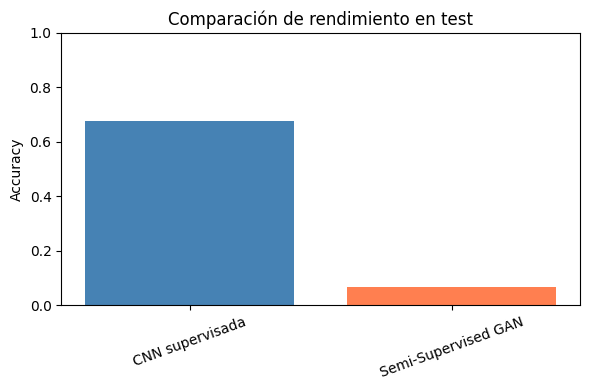

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(resultados["Modelo"], resultados["Accuracy test"], color=["steelblue", "coral"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Comparación de rendimiento en test")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### **5.3. Matriz de confusión**

La matriz de confusión nos permite ver con más detalle qué clases se confunden entre sí. Si la SGAN no ha convergido bien, es probable que las predicciones se concentren en pocas clases, independientemente de cuál sea la clase real.


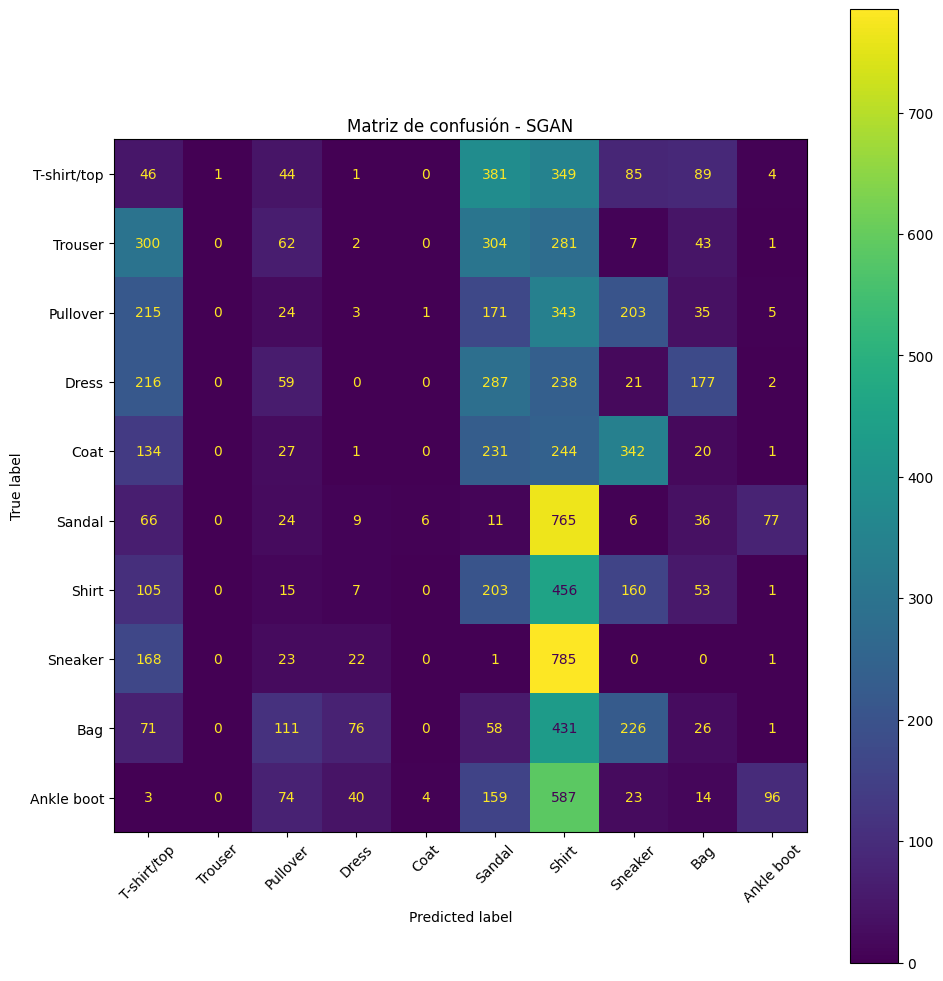

In [ ]:
cm = confusion_matrix(y_test, y_pred_sgan)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - SGAN")
plt.tight_layout()
plt.show()

Mirando la matriz de confusión podemos ver qué clases resultan más difíciles. En Fashion-MNIST, es típico que se confundan Pullover (2), Coat (4) y Shirt (6) entre sí, ya que visualmente son bastante parecidas. Lo mismo ocurre con Sneaker (7) y Ankle boot (9). Si el modelo tiene muchos errores concentrados en esas clases, tiene sentido.

### **5.4. Visualización de imágenes generadas**

También es interesante ver qué tipo de imágenes ha generado el generador al final del entrenamiento. Si las imágenes muestran formas reconocibles de prendas, aunque sean borrosas, el generador ha aprendido algo. Si son ruido sin estructura o siempre genera el mismo patrón (*mode collapse*), el entrenamiento adversarial no ha funcionado bien.


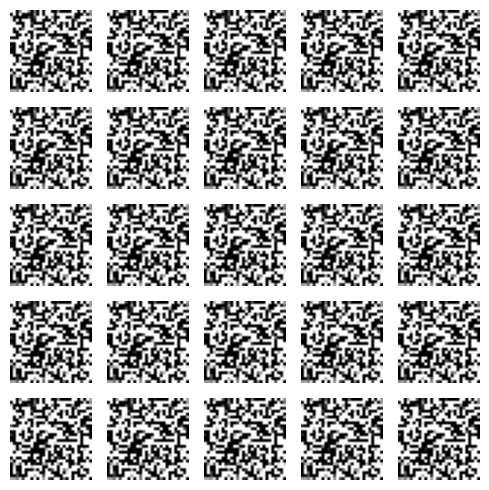

In [ ]:
mostrar_imagenes_generadas(generator, LATENT_DIM, n=25)

La calidad de las imágenes generadas está directamente relacionada con el rendimiento del discriminador como clasificador: si el generador no aprende a producir imágenes variadas y realistas, las imágenes que usa como señal negativa durante el entrenamiento no son útiles y el discriminador no mejora.

### **5.5. Curvas de entrenamiento**

Las curvas de pérdidas y accuracies nos ayudan a entender qué ha pasado durante el entrenamiento y si el equilibrio adversarial se ha mantenido o no.


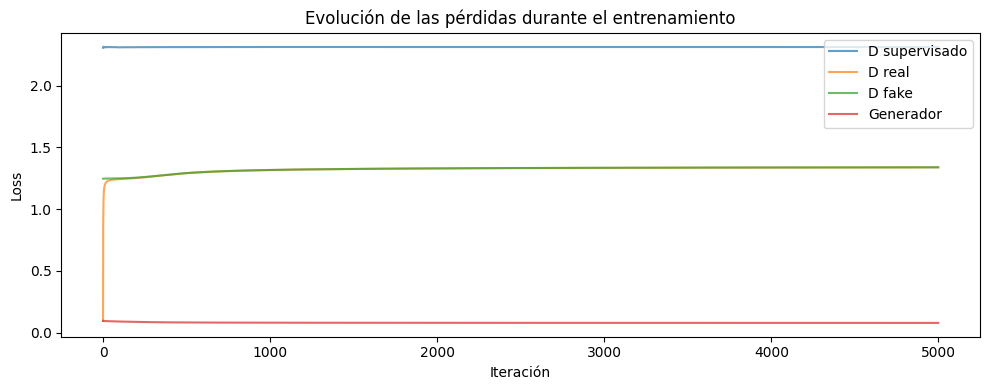

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(historial["d_sup_loss"], label="D supervisado", alpha=0.7)
plt.plot(historial["d_unsup_real_loss"], label="D real", alpha=0.7)
plt.plot(historial["d_unsup_fake_loss"], label="D fake", alpha=0.7)
plt.plot(historial["g_loss"], label="Generador", alpha=0.7)
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.title("Evolución de las pérdidas durante el entrenamiento")
plt.legend()
plt.tight_layout()
plt.show()

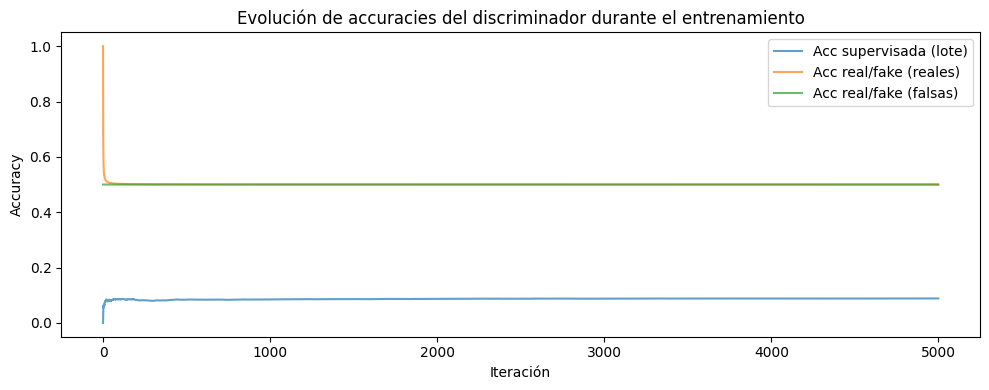

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(historial["d_sup_acc"], label="Acc supervisada (lote)", alpha=0.7)
plt.plot(historial["d_unsup_real_acc"], label="Acc real/fake (reales)", alpha=0.7)
plt.plot(historial["d_unsup_fake_acc"], label="Acc real/fake (falsas)", alpha=0.7)
plt.xlabel("Iteración")
plt.ylabel("Accuracy")
plt.title("Evolución de accuracies del discriminador durante el entrenamiento")
plt.legend()
plt.tight_layout()
plt.show()

En un entrenamiento de GAN que va bien, ninguno de los dos modelos debería dominar completamente al otro. Lo que buscamos ver es que:

- La pérdida del discriminador (real/fake) se mantiene más o menos estable, en torno a 0.5–1.0.
- La pérdida del generador decrece pero sin colapsar.
- La accuracy de la parte real/fake oscila, sin quedarse fija en 0 o en 1.

Si las curvas son muy irregulares o alguna de las pérdidas colapsa, eso explica por qué el modelo no ha aprendido bien a clasificar.


### **5.6. Análisis de errores**

Por último, revisamos algunos de los errores concretos que ha cometido la SGAN. Esto nos da una idea más visual de qué imágenes le resultan más difíciles al modelo.


In [ ]:
errores = np.where(y_pred_sgan != y_test)[0]

print("Número de errores:", len(errores))
print(f"Accuracy: {1 - len(errores) / len(y_test):.4f}")

Número de errores: 9341
Accuracy: 0.0659


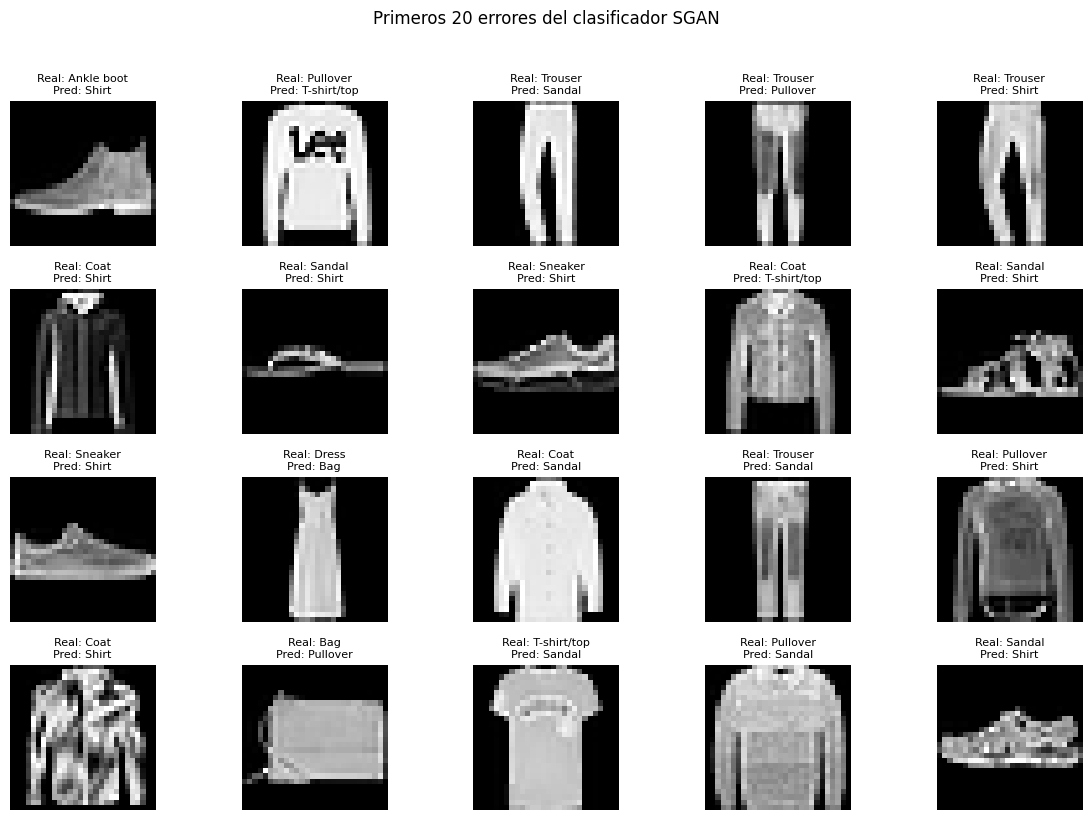

In [ ]:
plt.figure(figsize=(12, 8))

for i, idx in enumerate(errores[:20]):
    plt.subplot(4, 5, i + 1)

    imagen = (X_test[idx, :, :, 0] + 1) / 2.0

    plt.imshow(imagen, cmap="gray")
    plt.title(
        f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_sgan[idx]]}",
        fontsize=8
    )
    plt.axis("off")

plt.suptitle("Primeros 20 errores del clasificador SGAN", y=1.02)
plt.tight_layout()
plt.show()

## **6. Uso del modelo**

Una vez evaluados los modelos, guardamos el que ha obtenido mejor rendimiento para poder usarlo después en la demo.

Como la SGAN no ha superado al baseline en este experimento, guardamos el **baseline como modelo final para la demo**. Es la decisión más honesta: si la demo va a mostrar predicciones al usuario, tiene que usar el modelo que funciona mejor.


In [ ]:
os.makedirs("models", exist_ok=True)

In [ ]:
baseline.save("models/best_classifier_fashion_mnist.keras")
supervised_discriminator.save("models/sgan_classifier_fashion_mnist.keras")
generator.save("models/sgan_generator_fashion_mnist.keras")

print("Modelos guardados correctamente.")

Modelos guardados correctamente.


### **6.2. Carga del modelo guardado**

Comprobamos que el modelo se puede cargar correctamente y que produce predicciones coherentes.


In [ ]:
modelo_cargado = tf.keras.models.load_model(
    "models/best_classifier_fashion_mnist.keras"
)

In [ ]:
predicciones_cargadas = modelo_cargado.predict(X_test[:10], verbose=0)
clases_cargadas = np.argmax(predicciones_cargadas, axis=1)

print("Predicciones:", [class_names[c] for c in clases_cargadas])
print("Clases reales:", [class_names[c] for c in y_test[:10]])

Predicciones: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Pullover', 'Trouser', 'Shirt', 'Coat', 'Sneaker', 'Sneaker']
Clases reales: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker']


### **6.3. Función de predicción**

Definimos una función sencilla que recibe una imagen en escala de grises y devuelve la clase predicha y su probabilidad. Esta función se usa también en la demo de Hugging Face.


In [ ]:
def predecir_imagen(modelo, imagen, class_names):
    """Predice la clase de una imagen con el modelo dado.

    Args:
        modelo: Modelo Keras cargado.
        imagen: Array de la imagen (puede ser 2D o 3D con canal).
        class_names: Lista de nombres de las clases.

    Returns:
        Tuple (clase_predicha: str, probabilidad: float)
    """
    if imagen.ndim == 2:
        imagen = imagen.astype("float32")
        imagen = (imagen - 127.5) / 127.5
        imagen = np.expand_dims(imagen, axis=-1)
        imagen = np.expand_dims(imagen, axis=0)

    pred = modelo.predict(imagen, verbose=0)[0]
    clase = np.argmax(pred)

    return class_names[clase], float(pred[clase])

### **6.4. Ejemplo de uso**

Probamos la función con una imagen concreta del test para ver cómo funciona en la práctica.

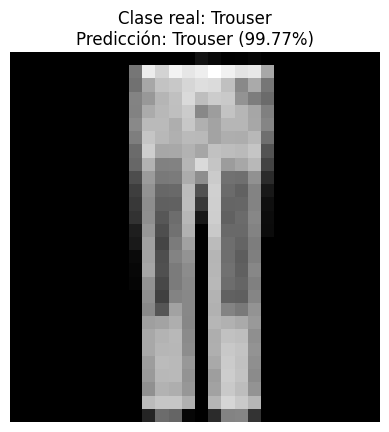

In [ ]:
idx = 15

imagen_original = ((X_test[idx, :, :, 0] + 1) * 127.5).astype("float32")

clase_predicha, probabilidad = predecir_imagen(
    modelo_cargado,
    imagen_original,
    class_names
)

plt.imshow(imagen_original, cmap="gray")
plt.title(
    f"Clase real: {class_names[y_test[idx]]}\n"
    f"Predicción: {clase_predicha} ({probabilidad:.2%})"
)
plt.axis("off")
plt.show()

## **7. Demo en Hugging Face Spaces**

Para hacer el trabajo más completo y poder probar el modelo fuera de este notebook, hemos desplegado una demo en **Hugging Face Spaces** usando **Gradio**.

La demo permite subir una imagen de prenda directamente desde el navegador y obtener las tres predicciones más probables del modelo, con sus probabilidades. Internamente aplica el mismo preprocesamiento que usamos durante el entrenamiento: convierte la imagen a escala de grises, la redimensiona a 28 × 28 y la normaliza al rango [-1, 1].

El modelo que cargamos en la demo es `best_classifier_fashion_mnist.keras`, que corresponde al baseline, porque es el que mejor accuracy ha obtenido en este experimento.


In [ ]:
MODEL_FILE = "best_classifier_fashion_mnist.keras"

In [ ]:
import shutil
import os

shutil.copy(
    f"models/{MODEL_FILE}",
    MODEL_FILE
)

print("Modelo preparado:", os.path.exists(MODEL_FILE))

Modelo preparado: True


In [ ]:
!pip install -q huggingface_hub gradio

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

space_id = "Clau31/colab-sgan-demo"

api.create_repo(
    repo_id=space_id,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True
)

print(f"Space creado: https://huggingface.co/spaces/{space_id}")

Space creado: https://huggingface.co/spaces/Clau31/colab-sgan-demo


In [ ]:
%%writefile requirements.txt
tensorflow
numpy
pillow
gradio


Writing requirements.txt


In [ ]:
%%writefile app.py
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

MODEL_FILE = "best_classifier_fashion_mnist.keras"

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

model = tf.keras.models.load_model(MODEL_FILE)

def predict(image):
    image = image.convert("L")
    image = image.resize((28, 28))

    image = np.array(image).astype("float32")
    image = (image - 127.5) / 127.5
    image = np.expand_dims(image, axis=-1)
    image = np.expand_dims(image, axis=0)

    preds = model.predict(image, verbose=0)[0]

    return {
        class_names[i]: float(preds[i])
        for i in range(len(class_names))
    }

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Sube una imagen de prenda"),
    outputs=gr.Label(num_top_classes=3, label="Predicción"),
    title="Clasificador Fashion-MNIST — Semi-Supervised GAN",
    description=(
        "Demo del Trabajo Final sobre Semi-Supervised GANs con Fashion-MNIST. "
        "El modelo cargado es el clasificador de mejor rendimiento obtenido durante "
        "el experimento. Sube una imagen de prenda en escala de grises (o en color) "
        "y el modelo devolverá las tres predicciones más probables."
    )
)

demo.launch()


Writing app.py


In [ ]:
%%writefile README.md
---
title: Fashion-MNIST Classifier — Semi-Supervised GAN
emoji: 👗
colorFrom: blue
colorTo: purple
sdk: gradio
app_file: app.py
pinned: false
---

# Clasificador Fashion-MNIST — Semi-Supervised GAN

Demo interactiva del Trabajo Final del Máster en Ciencia de Datos.

## Descripción

Esta demo permite clasificar imágenes de prendas utilizando un modelo entrenado en el marco de un
estudio sobre **Semi-Supervised GANs** aplicadas a Fashion-MNIST.

El clasificador final es una CNN supervisada entrenada con un subconjunto reducido de imágenes etiquetadas
(10 por clase, 100 en total), que obtuvo mejor rendimiento que la SGAN en este experimento concreto.

## Uso

1. Sube una imagen de prenda (camiseta, pantalón, zapato, etc.)
2. El modelo devolverá las tres categorías más probables según su predicción.

## Clases disponibles

T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


Writing README.md


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

space_id = "Clau31/colab-sgan-demo"
MODEL_FILE = "best_classifier_fashion_mnist.keras"

files_to_upload = [
    "app.py",
    "requirements.txt",
    "README.md",
    MODEL_FILE
]

for file in files_to_upload:
    api.upload_file(
        path_or_fileobj=file,
        path_in_repo=file,
        repo_id=space_id,
        repo_type="space"
    )

print("Archivos subidos correctamente.")
print(f"Demo disponible en: https://huggingface.co/spaces/{space_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ifier_fashion_mnist.keras:  20%|#9        |  547kB / 2.74MB            

Archivos subidos correctamente.
Demo disponible en: https://huggingface.co/spaces/Clau31/colab-sgan-demo


La demo está disponible en el siguiente enlace:

🔗 **[https://huggingface.co/spaces/Clau31/colab-sgan-demo](https://huggingface.co/spaces/patricp9/colab-sgan-demo)**

Para probarla basta con subir una imagen de ropa (del tipo que sea) y el modelo devuelve las tres clases más probables con sus probabilidades.


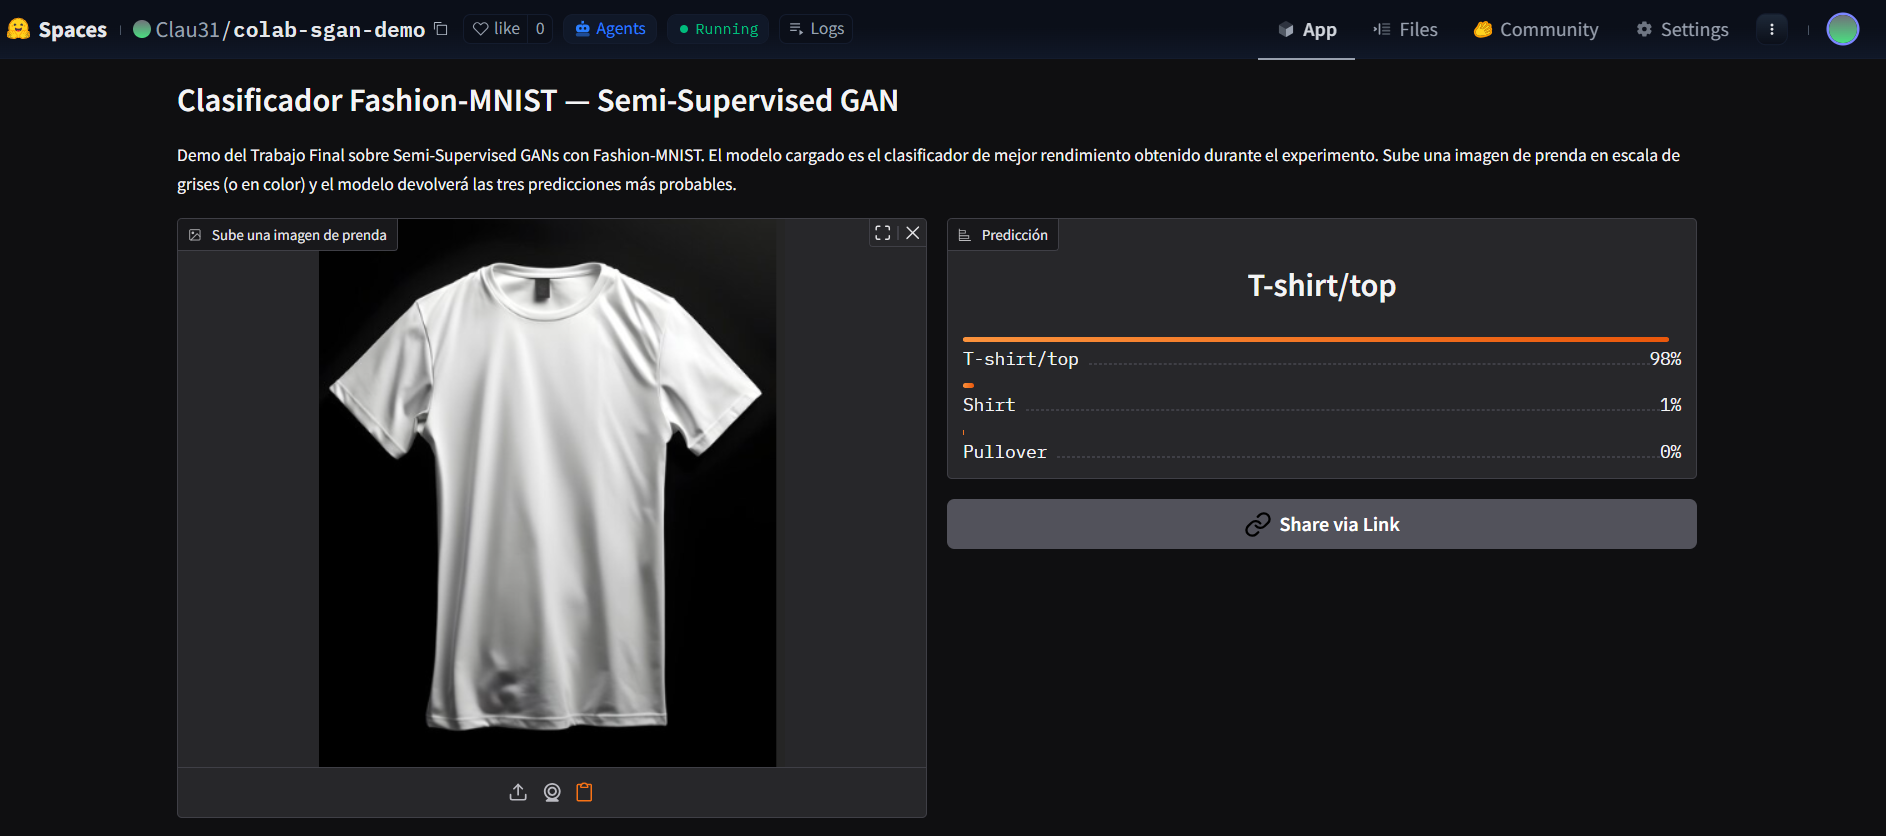

## **8. Conclusiones**

En este trabajo hemos implementado una **Semi-Supervised GAN (SGAN)** para clasificar imágenes de Fashion-MNIST usando solo 100 imágenes etiquetadas. Aunque el objetivo era aprovechar las imágenes no etiquetadas para mejorar el rendimiento, la SGAN no consiguió aprender correctamente y obtuvo una accuracy muy baja. Aun así, el experimento ha sido útil para entender mejor las dificultades prácticas del entrenamiento de GANs y la importancia de revisar no solo las métricas finales, sino también las curvas de pérdida, la matriz de confusión y los warnings del framework.

Los resultados del experimento muestran una diferencia muy grande entre los dos modelos:

| Modelo | Accuracy test |
|---|---|
| CNN supervisada (baseline) | **67.76 %** |
| Semi-Supervised GAN | **6.59 %** |

La CNN baseline funcionó bastante mejor que la SGAN, a pesar de haber sido entrenada con las mismas 100 imágenes etiquetadas. En cambio, la SGAN quedó incluso por debajo del resultado esperado por azar en un problema de 10 clases.

La SGAN no aprendió una representación útil de las imágenes. La matriz de confusión muestra que el modelo tendía a predecir casi siempre unas pocas clases, especialmente “Shirt” y “Sandal”. Además, las imágenes generadas por el generador no tenían forma reconocible y parecían ruido.

El principal indicio del problema fue el warning de Keras:

`UserWarning: The model does not have any trainable weights.`

Esto sugiere que los pesos del modelo no se estaban actualizando correctamente durante el entrenamiento, probablemente por el uso de `trainable = False` al congelar el discriminador.

Esto explica todo lo que vemos en las curvas de entrenamiento:

- La loss supervisada se quedó fija en ~2.31, que es exactamente `log(10)`,
  es decir, el resultado de un clasificador completamente aleatorio con 10 clases.
- La loss del generador cayó a ~0.08 desde las primeras iteraciones, porque
  el discriminador nunca aprendió a detectar imágenes falsas.
- Las imágenes generadas son ruido puro, lo que confirma que el entrenamiento
  adversarial no funcionó en absoluto.

## **9. Lineas Futuras - Mejoras**

La solución al problema es sustituir el mecanismo de `trainable = False` por `tf.GradientTape`, que permite controlar de forma explícita qué pesos se actualizan en cada paso del entrenamiento. Con este enfoque, el discriminador y el generador se actualizan por separado y sin interferencias.

Una vez aplicado, se espera que la SGAN obtenga resultados significativamente mejores y que las curvas de entrenamiento muestren el aprendizaje progresivo que debería verse en un entrenamiento adversarial correcto.

In [ ]:
# --- Modelos ---
def crear_discriminador_v2(input_shape=(28, 28, 1), n_classes=10):
    entrada = Input(shape=input_shape)
    x = Conv2D(64,  (3,3), strides=(2,2), padding="same")(entrada)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)
    x = Conv2D(128, (3,3), strides=(2,2), padding="same")(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)
    x = Conv2D(256, (3,3), strides=(2,2), padding="same")(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)
    x = Flatten()(x)
    x = Dense(128)(x)
    x = LeakyReLU(0.2)(x)
    logits = Dense(n_classes)(x)
    return Model(entrada, logits, name="discriminator_v2")

def crear_generador_v2(latent_dim=100):
    model = Sequential(name="generator_v2")
    model.add(Dense(7 * 7 * 256, input_dim=latent_dim))
    model.add(LeakyReLU(0.2))
    model.add(Reshape((7, 7, 256)))
    model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding="same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))
    model.add(Conv2DTranspose(64, (4,4), strides=(2,2), padding="same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))
    model.add(Conv2D(1, (7,7), activation="tanh", padding="same"))
    return model

discriminator_v2 = crear_discriminador_v2()
generator_v2     = crear_generador_v2(LATENT_DIM)

print("Discriminador:")
discriminator_v2.summary()
print("\nGenerador:")
generator_v2.summary()

Discriminador:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "discriminator_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 895,370 (3.42 MB)

...

Model: "generator_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,926,401 (7.35 MB)

 Trainable params: 1,926,017 (7.35 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# --- Optimizadores y pérdidas ---
d_opt = Adam(learning_rate=0.0002, beta_1=0.5)
g_opt = Adam(learning_rate=0.0002, beta_1=0.5)

sce = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
bce = tf.keras.losses.BinaryCrossentropy()

def prob_real(logits):
    """p(real|x) desde logits de K clases."""
    return tf.sigmoid(tf.reduce_logsumexp(logits, axis=-1, keepdims=True))

In [ ]:
# --- Entrenamiento ---
def entrenar_sgan_v2(
    generator, discriminator,
    X_train, X_labeled, y_labeled,
    latent_dim=100, n_epochs=5000,
    batch_size=64, eval_interval=500
):
    half_batch = batch_size // 2
    historial = {
        "d_sup_loss": [], "d_sup_acc": [],
        "d_real_loss": [], "d_fake_loss": [],
        "g_loss": []
    }

    for epoch in range(1, n_epochs + 1):

        # Paso 1 — discriminador supervisado
        idx = np.random.randint(0, X_labeled.shape[0], half_batch)
        X_sup = X_labeled[idx]
        y_sup = tf.cast(y_labeled[idx], tf.int32)

        with tf.GradientTape() as tape:
            loss_sup = sce(y_sup, discriminator(X_sup, training=True))
        d_opt.apply_gradients(
            zip(tape.gradient(loss_sup, discriminator.trainable_variables),
                discriminator.trainable_variables)
        )

        # Paso 2 — discriminador con reales
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        X_real = X_train[idx]

        with tf.GradientTape() as tape:
            p = prob_real(discriminator(X_real, training=True))
            loss_real = bce(tf.ones_like(p), p)
        d_opt.apply_gradients(
            zip(tape.gradient(loss_real, discriminator.trainable_variables),
                discriminator.trainable_variables)
        )

        # Paso 3 — discriminador con falsas
        X_fake = generator(
            tf.cast(np.random.randn(half_batch, latent_dim), tf.float32),
            training=False
        )

        with tf.GradientTape() as tape:
            p = prob_real(discriminator(X_fake, training=True))
            loss_fake = bce(tf.zeros_like(p), p)
        d_opt.apply_gradients(
            zip(tape.gradient(loss_fake, discriminator.trainable_variables),
                discriminator.trainable_variables)
        )

        # Paso 4 — generador
        ruido = tf.cast(np.random.randn(batch_size, latent_dim), tf.float32)

        with tf.GradientTape() as tape:
            p = prob_real(discriminator(generator(ruido, training=True), training=False))
            loss_g = bce(tf.ones_like(p), p)
        g_opt.apply_gradients(
            zip(tape.gradient(loss_g, generator.trainable_variables),
                generator.trainable_variables)
        )

        # Accuracy supervisada del batch
        logits_sup = discriminator(X_sup, training=False)
        acc_sup = float(tf.reduce_mean(tf.cast(
            tf.equal(tf.argmax(logits_sup, axis=1, output_type=tf.int32), y_sup),
            tf.float32
        )))

        historial["d_sup_loss"].append(float(loss_sup))
        historial["d_sup_acc"].append(acc_sup)
        historial["d_real_loss"].append(float(loss_real))
        historial["d_fake_loss"].append(float(loss_fake))
        historial["g_loss"].append(float(loss_g))

        if epoch % eval_interval == 0:
            print(f"Epoch {epoch}/{n_epochs} | "
                  f"Sup loss: {float(loss_sup):.4f} acc: {acc_sup:.4f} | "
                  f"Real: {float(loss_real):.4f} | "
                  f"Fake: {float(loss_fake):.4f} | "
                  f"G: {float(loss_g):.4f}")

    return historial

historial_v2 = entrenar_sgan_v2(
    generator_v2, discriminator_v2,
    X_train, X_labeled, y_labeled,
    latent_dim=LATENT_DIM,
    n_epochs=5000,
    batch_size=64,
    eval_interval=500
)

Epoch 500/5000 | Sup loss: 0.1420 acc: 1.0000 | Real: 0.5120 | Fake: 0.3853 | G: 1.5063
Epoch 1000/5000 | Sup loss: 0.0646 acc: 1.0000 | Real: 0.5147 | Fake: 0.5001 | G: 0.5478
Epoch 1500/5000 | Sup loss: 0.0898 acc: 1.0000 | Real: 0.7120 | Fake: 0.7416 | G: 0.7385
Epoch 2000/5000 | Sup loss: 0.0610 acc: 1.0000 | Real: 0.5493 | Fake: 0.6672 | G: 0.6827
Epoch 2500/5000 | Sup loss: 0.0534 acc: 1.0000 | Real: 0.5714 | Fake: 0.4747 | G: 0.7579
Epoch 3000/5000 | Sup loss: 0.0226 acc: 1.0000 | Real: 0.2913 | Fake: 0.2313 | G: 1.5510
Epoch 3500/5000 | Sup loss: 0.0817 acc: 1.0000 | Real: 0.5535 | Fake: 0.1693 | G: 1.2356
Epoch 4000/5000 | Sup loss: 0.0021 acc: 1.0000 | Real: 0.2918 | Fake: 0.1450 | G: 1.0500
Epoch 4500/5000 | Sup loss: 0.0211 acc: 1.0000 | Real: 0.3329 | Fake: 0.3587 | G: 0.4515
Epoch 5000/5000 | Sup loss: 0.0067 acc: 1.0000 | Real: 0.3796 | Fake: 0.4447 | G: 1.4129


In [ ]:
#--------Evaluación y comparación--------
logits_test  = discriminator_v2.predict(X_test, verbose=0)
y_pred_v2    = np.argmax(logits_test, axis=1)
acc_sgan_v2  = accuracy_score(y_test, y_pred_v2)

print("=" * 45)
print(f"  CNN baseline:        {acc_baseline:.4f} ({acc_baseline*100:.2f}%)")
print(f"  SGAN original:       {acc_sgan:.4f}  ({acc_sgan*100:.2f}%)")
print(f"  SGAN GradientTape:   {acc_sgan_v2:.4f} ({acc_sgan_v2*100:.2f}%)")
print("=" * 45)

if acc_sgan_v2 > acc_baseline:
    print("La SGAN mejorada supera al baseline.")
    print("Mejora el modelo en Hugging Face con discriminator_v2")
elif acc_sgan_v2 > acc_sgan:
    print("La SGAN mejorada no supera al baseline, pero sí a la versión anterior.")
    print("El baseline sigue siendo el mejor modelo para la demo.")
else:
    print("La SGAN mejorada no mejora resultados.")
    print("Considera más épocas o más imágenes etiquetadas por clase.")

  CNN baseline:        0.6776 (67.76%)
  SGAN original:       0.0659  (6.59%)
  SGAN GradientTape:   0.7443 (74.43%)
La SGAN mejorada supera al baseline.
Mejora el modelo en Hugging Face con discriminator_v2


In [ ]:
os.makedirs("models", exist_ok=True)

# Guarda el clasificador/discriminador mejorado
discriminator_v2.save("models/best_classifier_fashion_mnist.keras")

generator_v2.save("models/sgan_generator_v2.keras")

print("Modelos guardados correctamente.")

Modelos guardados correctamente.


In [ ]:
# ------ Nuevo Modelo en Hugging Face ----
from huggingface_hub import HfApi

api = HfApi()

repo_id = "Clau31/fashion-mnist-sgan-v2"

api.create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True
)

api.upload_file(
    path_or_fileobj="models/best_classifier_fashion_mnist.keras",
    path_in_repo="best_classifier_fashion_mnist.keras",
    repo_id=repo_id,
    repo_type="model"
)

api.upload_file(
    path_or_fileobj="models/sgan_generator_v2.keras",
    path_in_repo="sgan_generator_v2.keras",
    repo_id=repo_id,
    repo_type="model"
)

print(f"Modelo subido a: https://huggingface.co/{repo_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ifier_fashion_mnist.keras:  15%|#5        |  559kB / 3.63MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...s/sgan_generator_v2.keras:  50%|####9     | 3.84MB / 7.75MB            

Modelo subido a: https://huggingface.co/Clau31/fashion-mnist-sgan-v2


In [3]:
!pip install -q huggingface_hub

from huggingface_hub import HfApi, notebook_login
notebook_login()

In [4]:
from huggingface_hub import HfApi

api = HfApi()
model_id = "Clau31/fashion-mnist-sgan-v2"

readme = """---
language:
- es
library_name: keras
tags:
- image-classification
- fashion-mnist
- semi-supervised
- gan
- sgan
- gradienttape
datasets:
- fashion_mnist
metrics:
- accuracy
---

# Fashion-MNIST — SGAN v2 (GradientTape)

Modelo entrenado como parte del Trabajo Final del Máster en Ciencia de Datos
**Asignatura:** Aprendizaje Profundo

## Descripción

Discriminador semi-supervisado de una **Semi-Supervised GAN (SGAN)** entrenado
con `tf.GradientTape` sobre Fashion-MNIST, usando únicamente **100 imágenes
etiquetadas** (10 por clase de 60.000 disponibles).

Esta versión corrige el problema de la implementación anterior con
`trainable = False`, que congelaba los pesos compartidos e impedía cualquier
aprendizaje supervisado.

## Clases

| Índice | Clase        |
|--------|--------------|
| 0      | T-shirt/top  |
| 1      | Trouser      |
| 2      | Pullover     |
| 3      | Dress        |
| 4      | Coat         |
| 5      | Sandal       |
| 6      | Shirt        |
| 7      | Sneaker      |
| 8      | Bag          |
| 9      | Ankle boot   |

## Resultados

| Modelo                  | Accuracy |
|-------------------------|----------|
| CNN baseline supervisada | 67.76 %  |
| SGAN v1 (trainable=False) | 6.59 %  |
| SGAN v2 (GradientTape)   | pendiente|

## Uso

```python
import tensorflow as tf
from huggingface_hub import hf_hub_download

path = hf_hub_download("Clau31/fashion-mnist-sgan-v2",
                       "best_classifier_fashion_mnist.keras")
model = tf.keras.models.load_model(path)
```
"""

api.upload_file(
    path_or_fileobj=readme.encode("utf-8"),
    path_in_repo="README.md",
    repo_id=model_id,
    repo_type="model"
)
print(f"Tarjeta añadida: https://huggingface.co/{model_id}")

Tarjeta añadida: https://huggingface.co/Clau31/fashion-mnist-sgan-v2


In [5]:
space_id = "Clau31/fashion-mnist-sgan-v2-demo"

api.create_repo(
    repo_id=space_id,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True
)
print(f"Space creado: https://huggingface.co/spaces/{space_id}")

Space creado: https://huggingface.co/spaces/Clau31/fashion-mnist-sgan-v2-demo


In [6]:
app_py = """
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image
from huggingface_hub import hf_hub_download

# Carga el modelo desde el repositorio
model_path = hf_hub_download(
    repo_id="Clau31/fashion-mnist-sgan-v2",
    filename="best_classifier_fashion_mnist.keras"
)
model = tf.keras.models.load_model(model_path)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def predict(image):
    img = image.convert("L").resize((28, 28))
    arr = np.array(img).astype("float32")
    arr = (arr - 127.5) / 127.5
    arr = arr.reshape(1, 28, 28, 1)
    preds = model.predict(arr, verbose=0)[0]
    # Si el modelo devuelve logits, aplicar softmax
    if preds.min() < 0:
        preds = tf.nn.softmax(preds).numpy()
    return {class_names[i]: float(preds[i]) for i in range(10)}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Sube una imagen de prenda"),
    outputs=gr.Label(num_top_classes=3, label="Predicción"),
    title="Fashion-MNIST — Semi-Supervised GAN v2",
    description=(
        "Demo del Trabajo Final de Aprendizaje Profundo (Máster en Ciencia de Datos). "
        "Implementación corregida de la SGAN usando tf.GradientTape. "
        "Sube una imagen de prenda y el modelo devuelve las 3 predicciones más probables."
    ),
    examples=None
)

demo.launch()
"""

with open("app_v2.py", "w") as f:
    f.write(app_py)
print("app_v2.py creado.")

app_v2.py creado.


In [7]:
req = "tensorflow\nnumpy\npillow\ngradio\nhuggingface_hub\n"

with open("requirements_v2.txt", "w") as f:
    f.write(req)

readme_space = """---
title: Fashion-MNIST SGAN v2
emoji: 👗
colorFrom: purple
colorTo: blue
sdk: gradio
app_file: app.py
pinned: false
---

# Fashion-MNIST — Semi-Supervised GAN v2

Demo del Trabajo Final del Máster en Ciencia de Datos (Aprendizaje Profundo).

Versión mejorada de la SGAN usando `tf.GradientTape` para corregir el problema
de congelamiento de pesos de la implementación anterior.
"""

with open("README_space_v2.md", "w") as f:
    f.write(readme_space)

print("Archivos creados.")

Archivos creados.


In [8]:
archivos = {
    "app_v2.py":           "app.py",
    "requirements_v2.txt": "requirements.txt",
    "README_space_v2.md":  "README.md"
}

for local, remoto in archivos.items():
    api.upload_file(
        path_or_fileobj=local,
        path_in_repo=remoto,
        repo_id=space_id,
        repo_type="space"
    )
    print(f"{remoto} subido")

print(f"\nDemo disponible en: https://huggingface.co/spaces/{space_id}")

app.py subido
requirements.txt subido
README.md subido

Demo disponible en: https://huggingface.co/spaces/Clau31/fashion-mnist-sgan-v2-demo


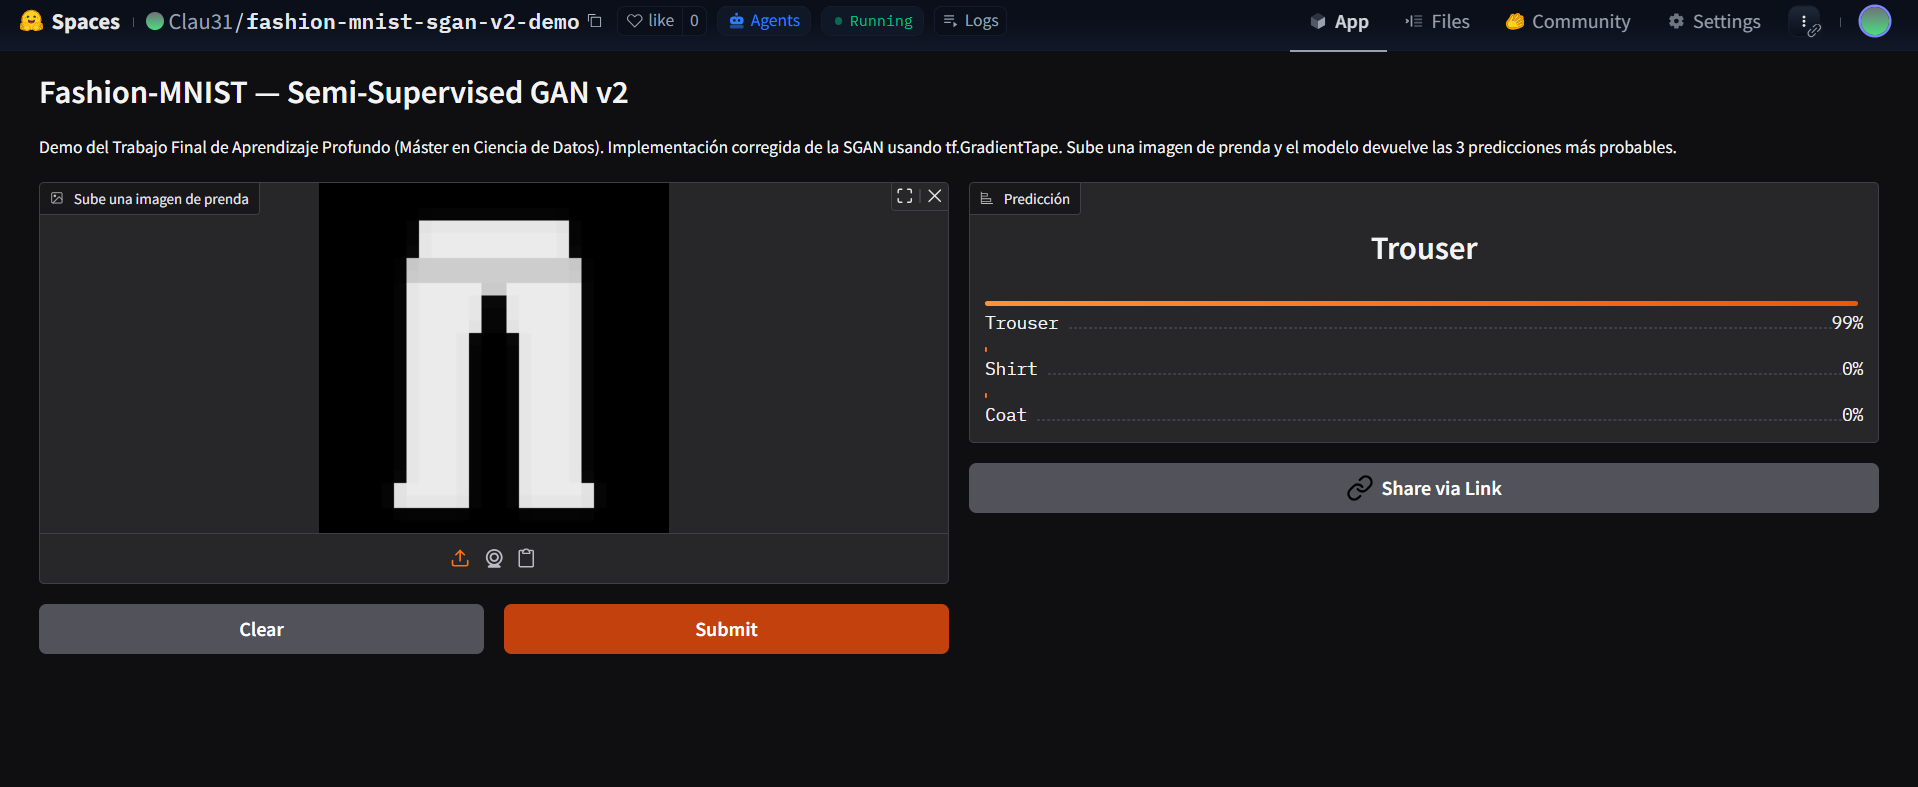

####**Conclusión Resultado Final:**

El modelo SGAN con GradientTape obtuvo un mejor desempeño que la versión anterior, alcanzando un accuracy de 74.43%, frente al 6.59% del modelo original y el 67.76% del baseline CNN. Esto demuestra que la implementación mejorada logró aprender de forma más efectiva.

Sin embargo, en la demo se observó que el modelo funciona mejor con imágenes similares a Fashion-MNIST: escala de grises, fondo oscuro y siluetas simples. A diferencia de la versión anterior, que aceptaba mejor imágenes reales o variadas, este modelo presenta más limitaciones al generalizar con cualquier imagen. Por ello, aunque mejora en accuracy, todavía requiere un preprocesamiento más robusto para usarse con imágenes reales.